# 05 — Training Concepts (ไม่ต้อง train จริง)

โน้ตบุ๊ก 01–04 ครอบคลุมกลไก attention ครบแล้ว แต่ยังมี **รายละเอียดฝั่ง training** ที่ paper ระบุไว้
และมีผลต่อว่าโมเดลจะ train สำเร็จหรือไม่ — ซึ่งอธิบายและสาธิตได้โดย**ไม่ต้อง train จริง**:

1. Learning rate warmup schedule (Noam)
2. Label smoothing
3. Embedding × √d_model
4. ตำแหน่งที่ใส่ Dropout

ทั้งหมดใช้ numpy + matplotlib รันบน CPU ได้ทันที

In [1]:
# P0 - Reproducibility (AGENTS.md #14)
import random

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

## 1. Learning Rate Warmup (Noam Schedule)

```text
lrate = d_model^(-0.5) · min(step^(-0.5), step · warmup_steps^(-1.5))
```

ค่าที่ paper ใช้: `warmup_steps = 4000`, Adam ที่ `β1=0.9, β2=0.98, ε=1e-9`
(ดู [`../docs/paper-notes.md`](../docs/paper-notes.md) หัวข้อ 9)

**สูตรนี้ทำงานอย่างไร:** มันคือการเลือกค่าที่ **น้อยกว่า** ระหว่างสองเส้น

- ช่วงแรก `step · warmup^(-1.5)` เล็กกว่า → learning rate **เพิ่มขึ้นแบบเส้นตรง** จากเกือบ 0
- หลังจาก `step = warmup_steps` เส้น `step^(-0.5)` เล็กกว่า → learning rate **ลดลงแบบ inverse square root**
- จุดสูงสุดจึงอยู่ที่ `step = warmup_steps` พอดี

**ทำไมต้อง warmup?** ตอนเริ่ม train weight ยังสุ่มอยู่ และ Adam ยังประมาณค่า moment (`β1`, `β2`)
จากตัวอย่างน้อยมาก ทำให้การประมาณนั้นแปรปรวนสูง ถ้าใช้ learning rate เต็มที่ทันทีตั้งแต่ step แรก
โมเดลอาจกระโดดไปยังจุดที่แย่มากจน train ไม่กลับมา (diverge) — warmup คือการ "ค่อย ๆ เร่ง"
เพื่อให้ Adam เก็บสถิติได้พอก่อนที่จะปล่อยความเร็วเต็มที่

In [2]:
# P1 - Noam learning rate schedule from the paper (section 5.3).
def noam_lr(step: int | np.ndarray, d_model: int = 512, warmup_steps: int = 4000):
    """step starts at 1 (step=0 would divide by zero)."""
    step = np.asarray(step, dtype=float)
    return d_model**-0.5 * np.minimum(step**-0.5, step * warmup_steps**-1.5)


steps = np.arange(1, 50_001)
lr_base = noam_lr(steps, d_model=512, warmup_steps=4000)

peak_step = int(steps[np.argmax(lr_base)])
print(f"peak learning rate at step {peak_step} (warmup_steps=4000) -> lr={lr_base.max():.3e}")
print(f"lr at step     1: {noam_lr(1):.3e}")
print(f"lr at step  4000: {noam_lr(4000):.3e}  <- peak")
print(f"lr at step 50000: {noam_lr(50000):.3e}")

peak learning rate at step 4000 (warmup_steps=4000) -> lr=6.988e-04
lr at step     1: 1.747e-07
lr at step  4000: 6.988e-04  <- peak
lr at step 50000: 1.976e-04


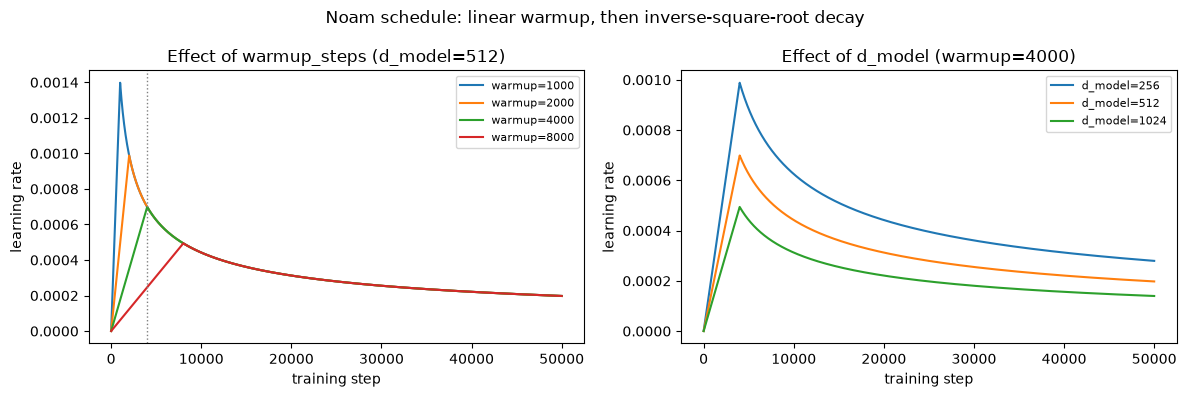

In [3]:
# P2 - Visualize the schedule: effect of warmup_steps and of d_model.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for warmup in (1000, 2000, 4000, 8000):
    axes[0].plot(steps, noam_lr(steps, 512, warmup), label=f"warmup={warmup}")
axes[0].axvline(4000, color="gray", linestyle=":", linewidth=1)
axes[0].set_title("Effect of warmup_steps (d_model=512)")

for dm in (256, 512, 1024):
    axes[1].plot(steps, noam_lr(steps, dm, 4000), label=f"d_model={dm}")
axes[1].set_title("Effect of d_model (warmup=4000)")

for ax in axes:
    ax.set_xlabel("training step")
    ax.set_ylabel("learning rate")
    ax.legend(fontsize=8)
fig.suptitle("Noam schedule: linear warmup, then inverse-square-root decay")
fig.tight_layout()
plt.show()

**อ่านกราฟอย่างไร:**

- **ซ้าย:** ยิ่ง `warmup_steps` มาก จุดสูงสุดยิ่งเลื่อนไปทางขวา **และค่าสูงสุดยิ่งต่ำลง** —
  เป็นผลจากสูตรโดยตรง (ที่จุดตัด lr = `d_model^(-0.5) · warmup^(-0.5)`) ดังนั้น warmup ไม่ได้แค่
  "ยืดเวลาอุ่นเครื่อง" แต่**เปลี่ยน learning rate สูงสุดของทั้งการเทรน**ไปด้วย เป็นสอง knob ที่ผูกกันอยู่
- **ขวา:** `d_model` ใหญ่ขึ้น → learning rate ต่ำลงทั้งเส้น (`d_model^(-0.5)`) สะท้อนสัญชาตญาณว่า
  โมเดลที่กว้างกว่าต้องก้าวเล็กลง เพราะ gradient ที่สะสมข้ามมิติจำนวนมากมีขนาดใหญ่กว่า

สังเกตว่ารูปทรงนี้ (ขึ้นเร็ว-ลงช้า) กลายเป็นมาตรฐานที่โมเดลยุคหลังยังใช้ต่อ แม้จะเปลี่ยนสูตรช่วงขาลง
เป็นแบบอื่น (เช่น cosine decay) ก็ยังคงส่วน warmup ไว้แทบทุกตัว

## 2. Label Smoothing

paper ใช้ `ε_ls = 0.1` และรายงานผลไว้ตรง ๆ ว่า:

> "This hurts perplexity, as the model learns to be more unsure, but improves accuracy and BLEU score."

**นี่คือ trade-off ที่ตั้งใจ ไม่ใช่การปรับปรุงทุกด้าน** — เป็นจุดที่มักถูกเข้าใจผิด

**ทำอะไร:** แทนที่จะบอกโมเดลว่า "คำตอบที่ถูกคือ token นี้ ความน่าจะเป็น 100%" (one-hot)
เราบอกว่า "ถูกประมาณ 90% ส่วนที่เหลือ 10% กระจายไปยัง token อื่น ๆ"

**ทำไปทำไม:** target แบบ one-hot ผลักให้โมเดลดัน logit ของคำตอบที่ถูกให้สูงขึ้นเรื่อย ๆ ไม่มีที่สิ้นสุด
(เพราะ softmax ไปถึง 1.0 ไม่ได้จริง) ทำให้โมเดล **มั่นใจเกินจริง (overconfident)** และ overfit
label smoothing ตั้งเพดานไว้ ทำให้โมเดลไม่สามารถ (และไม่จำเป็นต้อง) มั่นใจ 100%

*หมายเหตุ:* วิธีกระจาย `ε` ต่างกันเล็กน้อยในแต่ละ implementation (บางที่กระจายเท่ากันทุก class
บางที่ตัด `<pad>` ออก) ด้านล่างใช้แบบตรงไปตรงมา: class ที่ถูกได้ `1-ε` ที่เหลือแบ่ง `ε` เท่า ๆ กัน

In [4]:
# P1 - Label smoothing and its effect on the training target / loss floor.
def smooth_labels(target_idx: int, vocab_size: int, eps: float = 0.1) -> np.ndarray:
    """returns target distribution [vocab_size] summing to 1"""
    dist = np.full(vocab_size, eps / (vocab_size - 1))
    dist[target_idx] = 1.0 - eps
    return dist


def cross_entropy(pred_probs: np.ndarray, target_dist: np.ndarray) -> float:
    return float(-np.sum(target_dist * np.log(pred_probs + 1e-12)))


VOCAB, TARGET, EPS = 10, 3, 0.1
one_hot = np.zeros(VOCAB)
one_hot[TARGET] = 1.0
smoothed = smooth_labels(TARGET, VOCAB, EPS)

print(f"one-hot  target: {np.round(one_hot, 4)}")
print(f"smoothed target: {np.round(smoothed, 4)}  (sum={smoothed.sum():.3f})")

# A "perfect" model that puts ~all probability on the correct token.
confident = np.full(VOCAB, 1e-6)
confident[TARGET] = 1.0 - 1e-6 * (VOCAB - 1)

print(f"\nloss of a fully-confident model vs one-hot target : {cross_entropy(confident, one_hot):.4f}")
print(f"loss of a fully-confident model vs smoothed target: {cross_entropy(confident, smoothed):.4f}")
print("\n-> with label smoothing the loss can never reach 0: there is a permanent floor,")
print("   which is exactly why the paper reports that perplexity gets worse.")

one-hot  target: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
smoothed target: [0.0111 0.0111 0.0111 0.9    0.0111 0.0111 0.0111 0.0111 0.0111 0.0111]  (sum=1.000)

loss of a fully-confident model vs one-hot target : 0.0000
loss of a fully-confident model vs smoothed target: 1.3816

-> with label smoothing the loss can never reach 0: there is a permanent floor,
   which is exactly why the paper reports that perplexity gets worse.


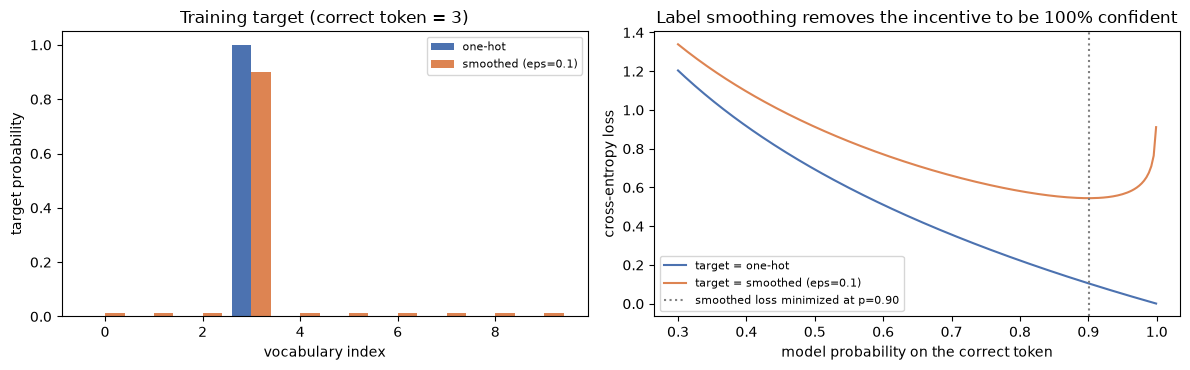

In [5]:
# P2 - Visualize the target distribution and the loss floor it creates.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

width = 0.4
idx = np.arange(VOCAB)
axes[0].bar(idx - width / 2, one_hot, width, label="one-hot", color="#4C72B0")
axes[0].bar(idx + width / 2, smoothed, width, label=f"smoothed (eps={EPS})", color="#DD8452")
axes[0].set_xlabel("vocabulary index")
axes[0].set_ylabel("target probability")
axes[0].set_title(f"Training target (correct token = {TARGET})")
axes[0].legend(fontsize=8)

# How loss varies with how confident the model is about the correct token.
confidences = np.linspace(0.30, 0.999, 200)
loss_one_hot, loss_smoothed = [], []
for p in confidences:
    probs = np.full(VOCAB, (1 - p) / (VOCAB - 1))
    probs[TARGET] = p
    loss_one_hot.append(cross_entropy(probs, one_hot))
    loss_smoothed.append(cross_entropy(probs, smoothed))

axes[1].plot(confidences, loss_one_hot, label="target = one-hot", color="#4C72B0")
axes[1].plot(confidences, loss_smoothed, label=f"target = smoothed (eps={EPS})", color="#DD8452")
best = confidences[int(np.argmin(loss_smoothed))]
axes[1].axvline(best, color="gray", linestyle=":", label=f"smoothed loss minimized at p={best:.2f}")
axes[1].set_xlabel("model probability on the correct token")
axes[1].set_ylabel("cross-entropy loss")
axes[1].set_title("Label smoothing removes the incentive to be 100% confident")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

**อ่านกราฟขวาให้ดี — นี่คือหัวใจของ label smoothing:**

- เส้นน้ำเงิน (one-hot): loss ลดลงเรื่อย ๆ ไม่มีที่สิ้นสุดเมื่อโมเดลมั่นใจขึ้น → โมเดลถูก "จูงใจ"
  ให้ดัน probability เข้าใกล้ 1.0 ตลอดเวลา ไม่มีจุดหยุด
- เส้นส้ม (smoothed): loss มี **จุดต่ำสุดที่ชัดเจน** (เส้นประ) แล้วกลับ **สูงขึ้น** ถ้ามั่นใจเกินจุดนั้น
  → โมเดลถูกจูงใจให้หยุดอยู่ที่ระดับความมั่นใจที่พอดี ไม่ใช่สุดโต่ง

นี่อธิบายคำที่ paper ใช้ ("the model learns to be more unsure") ได้ตรงตัว: perplexity แย่ลงเพราะ
โมเดลไม่ได้ถูกฝึกให้มั่นใจสูงสุดอีกต่อไป แต่ accuracy/BLEU ดีขึ้นเพราะโมเดลไม่ overfit กับคำตอบเดียว
และเผื่อความเป็นไปได้อื่นไว้ ซึ่งสำคัญมากในงานแปลภาษาที่ "คำตอบที่ถูก" มีได้หลายแบบ

## 3. Embedding × √d_model

paper ระบุไว้ในหัวข้อ 3.4 (Embeddings and Softmax):

> "In our model, we share the same weight matrix between the two embedding layers and the pre-softmax
> linear transformation... In the embedding layers, we multiply those weights by √d_model."

**Paper Finding:** ระบุแค่ *ว่าทำ* แต่ไม่ได้อธิบายเหตุผลไว้ในตัวบทความ

**Interpretation (คำอธิบายที่ยอมรับกันทั่วไป ไม่ใช่คำกล่าวของผู้เขียน):** embedding มักถูก initialize
ด้วย variance ประมาณ `1/d_model` ทำให้ค่าที่ได้เล็กมาก ในขณะที่ positional encoding เป็น `sin`/`cos`
ซึ่งมีค่าอยู่ในช่วง `[-1, 1]` เสมอไม่ว่า `d_model` จะเท่าไหร่ — ถ้าเอามาบวกกันตรง ๆ **positional encoding
จะกลบ embedding จนแทบไม่เหลือข้อมูลว่า token คืออะไร** การคูณ `√d_model` ดึง scale ของ embedding
ขึ้นมาให้เทียบเคียงกับ positional encoding ได้ ลองดูตัวเลขจริง:

In [6]:
# P1 - Why embeddings are multiplied by sqrt(d_model): magnitude vs positional encoding.
import sys
from pathlib import Path

shared_src = Path.cwd().resolve().parents[2] / "shared" / "src"
if str(shared_src) not in sys.path:
    sys.path.insert(0, str(shared_src))

from attention import positional_encoding

d_model, seq_len, vocab = 512, 20, 1000

# Common initialization: variance ~ 1/d_model
embedding_table = rng.normal(0, d_model**-0.5, size=(vocab, d_model))
token_ids = rng.integers(0, vocab, size=seq_len)

emb_raw = embedding_table[token_ids]  # [seq_len, d_model]
emb_scaled = emb_raw * np.sqrt(d_model)
pe = positional_encoding(seq_len, d_model)

print(f"std of raw embedding    : {emb_raw.std():.4f}")
print(f"std of positional encoding: {pe.std():.4f}")
print(f"ratio PE/embedding (raw) : {pe.std() / emb_raw.std():.1f}x  <- PE dominates")
print()
print(f"std of scaled embedding (x sqrt({d_model})={np.sqrt(d_model):.1f}): {emb_scaled.std():.4f}")
print(f"ratio PE/embedding (scaled): {pe.std() / emb_scaled.std():.2f}x  <- comparable")

# How much of the summed signal comes from the token identity vs its position?
for name, emb in (("without scaling", emb_raw), ("with scaling", emb_scaled)):
    total = emb + pe
    share = emb.std() / (emb.std() + pe.std())
    print(f"\n{name}: embedding contributes ~{share:.1%} of the summed signal's spread")
    print(f"  std(embedding + PE) = {total.std():.4f}")

std of raw embedding    : 0.0440
std of positional encoding: 0.5502
ratio PE/embedding (raw) : 12.5x  <- PE dominates

std of scaled embedding (x sqrt(512)=22.6): 0.9945
ratio PE/embedding (scaled): 0.55x  <- comparable

without scaling: embedding contributes ~7.4% of the summed signal's spread
  std(embedding + PE) = 0.5524

with scaling: embedding contributes ~64.4% of the summed signal's spread
  std(embedding + PE) = 1.1421


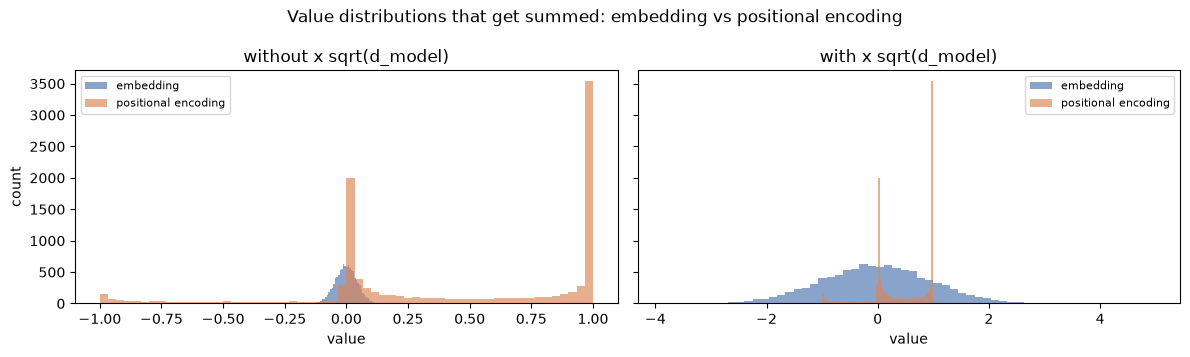

In [7]:
# P2 - Visualize how scaling changes the balance between token identity and position.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)

for ax, (emb, title) in zip(
    axes,
    ((emb_raw, "without x sqrt(d_model)"), (emb_scaled, "with x sqrt(d_model)")),
):
    ax.hist(emb.ravel(), bins=60, alpha=0.65, label="embedding", color="#4C72B0")
    ax.hist(pe.ravel(), bins=60, alpha=0.65, label="positional encoding", color="#DD8452")
    ax.set_title(title)
    ax.set_xlabel("value")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
fig.suptitle("Value distributions that get summed: embedding vs positional encoding")
fig.tight_layout()
plt.show()

**อ่านกราฟและตัวเลขอย่างไร:** ฝั่งซ้าย การกระจายของ embedding (น้ำเงิน) แคบมากจนเกือบเป็นแท่งเดียว
ตรงกลาง (std ≈ `0.044`) เทียบกับ positional encoding (ส้ม) ที่กระจายเต็มช่วง `[-1, 1]` (std ≈ `0.550`)
— ต่างกันถึง **12.5 เท่า** เมื่อบวกกัน embedding มีส่วนในความแปรปรวนของสัญญาณรวมแค่ **~7%**
ข้อมูล "token นี้คืออะไร" จึงเกือบถูกกลบหมดโดย "token นี้อยู่ตำแหน่งไหน"

ฝั่งขวาหลังคูณ `√512 ≈ 22.6` embedding มี std ≈ `0.995` ใกล้เคียงกับ PE (อัตราส่วนเหลือ `0.55`)
และมีส่วนในสัญญาณรวมเป็น **~64%** — ทั้งสองอยู่ในระดับเดียวกันแล้ว (ไม่ได้เท่ากันเป๊ะ แต่ไม่มีฝ่ายใด
ถูกกลบจนหายไป ซึ่งต่างจากก่อนคูณอย่างชัดเจน)

*ข้อควรระวัง:* ตัวเลขเหล่านี้ขึ้นกับ **วิธี initialize embedding** ที่เราเลือกใช้ (`std = 1/√d_model`)
ซึ่งเป็นค่าที่พบบ่อยแต่ไม่ใช่ค่าเดียวที่ใช้กันจริง — ถ้า init ด้วยวิธีอื่น สัดส่วนก็จะเปลี่ยนไป
ประเด็นที่ยังคงเดิมคือ *ทิศทาง* ของผล ไม่ใช่ตัวเลขที่แน่นอน

## 4. ตำแหน่งที่ใส่ Dropout

paper ระบุไว้ชัดเจนว่าใส่ dropout ตรงไหนบ้าง (`P_drop = 0.1` สำหรับ base model):

> "We apply dropout to the output of each sub-layer, before it is added to the sub-layer input and
> normalized. In addition, we apply dropout to the sums of the embeddings and the positional
> encodings in both the encoder and decoder stacks."

แปลเป็นลำดับการทำงานจริง:

```text
x
  ↓
Sublayer(x)              ← multi-head attention หรือ FFN
  ↓
Dropout(...)             ← ใส่ตรงนี้ ก่อนบวก residual
  ↓
LayerNorm(x + ...)       ← แล้วค่อย Add & Norm
```

และอีกจุด:

```text
Dropout(Embedding(tokens) × √d_model + PositionalEncoding)
```

**จุดที่ควรระวัง:** dropout อยู่ **ก่อน** การบวก residual ไม่ใช่หลัง — ถ้าใส่หลัง Add & Norm
จะเป็นการรบกวนทางลัดของ gradient (residual path) ที่ตั้งใจให้สะอาด ซึ่งทำให้ข้อดีของ residual
ตามที่อธิบายไว้ใน [`02_from_scratch.ipynb`](02_from_scratch.ipynb) §11 ลดลง

(โน้ตบุ๊กนี้ไม่ implement dropout เพราะเราไม่ได้ train — dropout ทำงานเฉพาะตอน training
และถูกปิดตอน inference อยู่แล้ว)

## สรุป

สี่เรื่องในโน้ตบุ๊กนี้ไม่ได้เปลี่ยนสถาปัตยกรรมเลย — โมเดลยังเป็น Transformer ตัวเดิม — แต่**เป็นตัวตัดสิน
ว่าการ train จะสำเร็จหรือพัง**:

| เรื่อง | ถ้าไม่ทำจะเกิดอะไร |
|---|---|
| Warmup schedule | learning rate เต็มที่ตั้งแต่ step แรกกับ weight ที่ยังสุ่ม → เสี่ยง diverge |
| Label smoothing | โมเดล overconfident, overfit — perplexity ดูดีขึ้นแต่ BLEU แย่ลง |
| Embedding × √d_model | positional encoding กลบข้อมูล token identity |
| ตำแหน่ง Dropout | ใส่ผิดที่ → รบกวน residual path หรือ regularize ไม่ได้ผล |

**ข้อจำกัดของโน้ตบุ๊กนี้:** ทุกอย่างเป็นการอธิบายกลไกและสาธิตเชิงตัวเลข **ไม่ได้พิสูจน์ด้วยการ train จริง**
เช่น เราไม่ได้แสดงว่าถ้าเอา warmup ออกแล้วโมเดลจะ diverge จริงหรือไม่ — ข้อสรุปเรื่องผลกระทบ
จึงอ้างอิงจากสิ่งที่ paper รายงานและเหตุผลเชิงกลไก ไม่ใช่หลักฐานจากแล็บนี้เอง